# Radiative consistency with Anderson (2013)

At $T_0$, every radiative line of `AndersonModelUnfolded` must match its counterpart in `AndersonModel`.
Level 6 is recomposed by summing the lines leaving $6s$ and $6h$ toward the same level:
$\text{rad6s}j + \text{rad6h}j \leftrightarrow \text{rad6}j$.

`k_r6s` and `k_r6h` are the model defaults: Anderson's $k^{rad}_6$ split with the $R_{HS}$ fit to Yu 2014.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pint import get_application_registry
from poincare import solvers

from upconversion_models import AndersonModel, AndersonModelUnfolded, cmap
from upconversion_models.jablonski_patch import (
    EmissionTransform,
    PulsedExcitation,
    Simulator,
    SteadyState,
)
from upconversion_models.utils import c, h, k

u = get_application_registry()
pd.set_option("display.float_format", "{:.2e}".format)

# Reference T of the Ref rates in the model (T0 = 300 K).
# paper.ipynb uses 293.15 K for fs0, ks, kh: at that T blue deviates ~9% from Anderson.
T_check = AndersonModelUnfolded.T0.default
THRESHOLD = 1e-2

### $k^{rad}_{6s}$, $k^{rad}_{6h}$ (model defaults)

In [2]:
ks = AndersonModelUnfolded.k_r6s.default.to(1 / u.s).magnitude
kh = AndersonModelUnfolded.k_r6h.default.to(1 / u.s).magnitude
ks, kh

(1366, 2086)

In [3]:
solver = solvers.LSODA(rtol=1e-10, atol=1e-12)

sim_and = (
    Simulator(AndersonModel())
    .with_solver(solver)
    .with_transform(EmissionTransform(kind="emission"), append=True)
)
sim_unf = (
    Simulator(AndersonModelUnfolded())
    .with_solver(solver)
    .with_transform(EmissionTransform(kind="emission"), append=True)
    .with_values(
        {
            AndersonModelUnfolded.k_r6s: ks / u.s,
            AndersonModelUnfolded.k_r6h: kh / u.s,
            AndersonModelUnfolded.T: T_check,
        }
    )
)

LINES = ["rad", "rad81", "rad82", "rad83", "rad85", "rad61", "rad62", "rad63",
         "rad51", "rad52", "rad53", "rad31", "rad32", "rad2"]


def recompose(df):
    # Unfolded lines renamed as Anderson's: rad6sj + rad6hj -> rad6j
    out = df.copy()
    for j in (1, 2, 3):
        out[f"line_rad6{j}"] = out.pop(f"line_rad6s{j}") + out.pop(f"line_rad6h{j}")
    return out[[f"line_{l}" for l in LINES]]

### Steady state vs excitation (Fig 4 range)
Maximum relative deviation $|I_{unf}/I_{and} - 1|$ over the sweep.

In [4]:
fluxes = np.linspace(1, 100, 34) * u.W / u.cm**2
ss_and = SteadyState().sweep(sim_and, variable=AndersonModel.energy_flux, values=fluxes)
ss_unf = SteadyState().sweep(sim_unf, variable=AndersonModelUnfolded.energy_flux, values=fluxes)

df_and = ss_and.to_dataframe()[[f"line_{l}" for l in LINES]]
df_unf = recompose(ss_unf.to_dataframe())
df_unf.index = df_and.index

steady_dev = (df_unf / df_and - 1).abs().max()
steady_dev

line_rad     4.54e-04
line_rad81   6.28e-03
line_rad82   6.28e-03
line_rad83   6.28e-03
line_rad85   6.28e-03
line_rad61   1.99e-03
line_rad62   1.99e-03
line_rad63   1.99e-03
line_rad51   1.84e-02
line_rad52   1.84e-02
line_rad53   1.84e-02
line_rad31   4.45e-04
line_rad32   4.45e-04
line_rad2    7.38e-04
dtype: float64

### Pulse (Fig 2: 30 mJ/cm², 10 µs)
Maximum deviation normalized to each line's peak, $\max_t |I_{unf} - I_{and}| / \max_t I_{and}$.

In [5]:
pulse_width = 1e-5 * u.s
pulse = PulsedExcitation(
    pulse_width=pulse_width,
    pulse_height=30e-3 * u.J / u.cm**2 / pulse_width,
    pump="energy_flux",
)
save_at = np.linspace(0, 2e-3, 1000) * u.s

pl_and = pulse.solve(sim_and, save_at=save_at).pint.dequantify().to_dataframe()[[f"line_{l}" for l in LINES]]
pl_unf = recompose(pulse.solve(sim_unf, save_at=save_at).pint.dequantify().to_dataframe())

pulse_dev = (pl_unf - pl_and).abs().max() / pl_and.abs().max()

In [6]:
report = pd.DataFrame({"steady": steady_dev, "pulse": pulse_dev})
report["ok"] = report.max(axis=1) < THRESHOLD
report

,steady,pulse,ok
line_rad,4.54e-04,2.08e-04,True
line_rad81,6.28e-03,5.85e-03,True
line_rad82,6.28e-03,5.85e-03,True
line_rad83,6.28e-03,5.85e-03,True
line_rad85,6.28e-03,5.85e-03,True
line_rad61,1.99e-03,2.59e-03,True
line_rad62,1.99e-03,2.59e-03,True
line_rad63,1.99e-03,2.59e-03,True
line_rad51,1.84e-02,1.57e-02,False
line_rad52,1.84e-02,1.57e-02,False


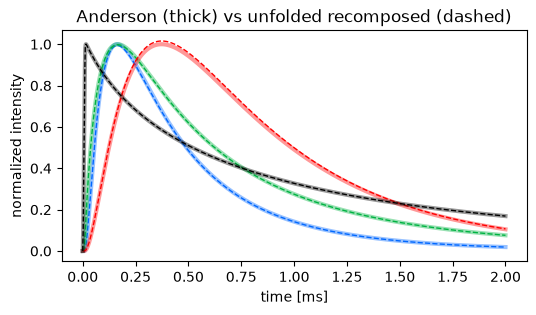

In [7]:
fig, ax = plt.subplots(figsize=(6, 3))
for line, color in [("line_rad81", cmap["b"]), ("line_rad61", cmap["g"]), ("line_rad51", cmap["r"]), ("line_rad31", "black")]:
    ax.plot(pl_and.index * 1e3, pl_and[line] / pl_and[line].max(), color=color, lw=3, alpha=0.4)
    ax.plot(pl_unf.index * 1e3, pl_unf[line] / pl_and[line].max(), color=color, lw=1, ls="--")
ax.set_xlabel("time [ms]")
ax.set_ylabel("normalized intensity")
ax.set_title("Anderson (thick) vs unfolded recomposed (dashed)")
plt.show()

### Temperature dependence (70–500 K)
Ratio of each recomposed line to Anderson's (which does not depend on T), at 5 W/cm².
At $T_0$ it must be ≈ 1; the departure from 1 is the temperature effect added by the unfolding
and the non-radiative transitions (with their upward partners by detailed balance).

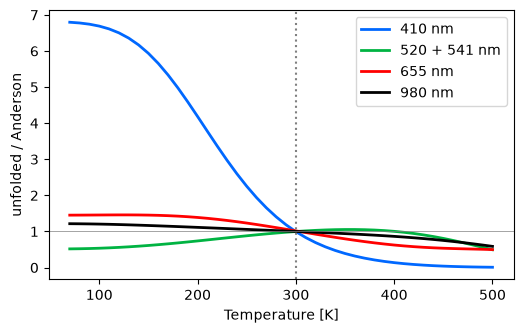

In [8]:
Ts = np.linspace(70, 500, 44) * u.K
flux = {AndersonModel.energy_flux: 5 * u.W / u.cm**2}
ref = SteadyState().solve(sim_and.with_values(flux)).pint.dequantify()
ts_unf = SteadyState().sweep(
    sim_unf.with_values({AndersonModelUnfolded.energy_flux: 5 * u.W / u.cm**2}),
    variable=AndersonModelUnfolded.T,
    values=Ts,
)
df_T = recompose(ts_unf.to_dataframe())

fig, ax = plt.subplots(figsize=(6, 3.5))
for line, color, label in [
    ("line_rad81", cmap["b"], "410 nm"),
    ("line_rad61", cmap["g"], "520 + 541 nm"),
    ("line_rad51", cmap["r"], "655 nm"),
    ("line_rad31", "black", "980 nm"),
]:
    ax.plot(Ts.magnitude, df_T[line] / float(np.ravel(ref[line].values)[-1]), color=color, lw=2, label=label)
ax.axvline(T_check.magnitude, color="gray", ls=":")
ax.axhline(1, color="gray", lw=0.5)
ax.set_xlabel("Temperature [K]")
ax.set_ylabel("unfolded / Anderson")
ax.legend()
plt.show()